# Train Tfh17 signature in CD4mem

In [1]:
# load packages
import glob
import os
import random

import anndata as ad
import celltypist
import h5py
import hisepy as hp
import matplotlib
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as scs
import seaborn as sns
from celltypist import models
from matplotlib import pyplot as plt
from scipy.stats import median_abs_deviation

In [18]:
# define working path
data_path = "/home/workspace/private/ra-cohort-ide/ALTRA_revision/Tfh17_followup/validation_data/"
fig_path = (
    "/home/workspace/private/ra-cohort-ide/ALTRA_revision/Tfh17_followup/figures/"
)
meta_path = "/home/jupyter/github/ra-longitudinal/metadata/"
output_path = "/home/workspace/private/ra-cohort-ide/ALTRA_revision/Tfh17_followup/validation_data/output_results/"

# define a project name
proj_name = "ALTRA_validation_tfh17_"
# sc.set_figure_params(fig_path)
sc.settings.figdir = fig_path
sc.settings.autosave = False
sc.set_figure_params(vector_friendly=True, dpi_save=300)
matplotlib.rcParams["pdf.fonttype"] = 42

# load CD4 mem data

In [3]:
# download data
hp.cache_files(
    ["6de3ba28-d25e-43e5-a221-b9ac0acf91d3", "609f7543-d4d5-41e9-a3d2-8e50c3e7c61d"]
)

['/home/workspace/input/569004694/UCSDCU_Y4/6de3ba28-d25e-43e5-a221-b9ac0acf91d3/ALTRA_scRNA_Non_Naive_CD4_Tcells_clean_obj.h5ad',
 '/home/workspace/input/569004694/UCSDCU_Y4/609f7543-d4d5-41e9-a3d2-8e50c3e7c61d/ALTRA_certPro_scRNA_141_samples_combined_adata.h5ad']

In [4]:
# load the deep clean data for T memory
# use backend to preseve memory
cd4mem_adata = sc.read_h5ad(
    "/home/workspace/input/569004694/UCSDCU_Y4/6de3ba28-d25e-43e5-a221-b9ac0acf91d3/ALTRA_scRNA_Non_Naive_CD4_Tcells_clean_obj.h5ad",
    backed="r",
)

In [5]:
cd4mem_adata

AnnData object with n_obs × n_vars = 460544 × 33538 backed at '/home/workspace/input/569004694/UCSDCU_Y4/6de3ba28-d25e-43e5-a221-b9ac0acf91d3/ALTRA_scRNA_Non_Naive_CD4_Tcells_clean_obj.h5ad'
    obs: 'barcodes', 'batch_id', 'cell_name', 'cell_uuid', 'chip_id', 'hto_barcode', 'hto_category', 'n_genes', 'n_mito_umis', 'n_reads', 'n_umis', 'original_barcodes', 'pbmc_sample_id', 'pool_id', 'well_id', 'sample.sampleKitGuid', 'cohort.cohortGuid', 'subject.subjectGuid', 'subject.biologicalSex', 'subject.race', 'subject.ethnicity', 'subject.birthYear', 'sample.visitName', 'sample.drawDate', 'sample.diseaseStatesRecordedAtVisit', 'sample.daysSinceFirstVisit', 'file.id', 'subset_grp', 'predicted_doublet', 'doublet_score', 'AIFI_L1', 'AIFI_L1_score', 'AIFI_L2', 'AIFI_L2_score', 'AIFI_L3', 'AIFI_L3_score', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_t

## load Fan Zhang 2019 Nature signature

In [6]:
tph_genes = [
    "CXCL13",
    "RNF19A",
    "DUSP4",
    "PDCD1",
    "TOX2",
    "MAF",
    "CTLA4",
    "TSHZ2",
    "TIGIT",
    "SNX9",
    "PTPN13",
    "NR3C1",
    "ITM2A",
    "FKBP5",
    "TP53INP1",
    "ARID5B",
    "TOX",
    "COTL1",
    "AHI1",
    "ZNRF1",
]

In [7]:
cd4mem_adata_sub = cd4mem_adata[:, cd4mem_adata.var_names.isin(tph_genes)].to_memory()

In [8]:
cd4mem_adata_sub

AnnData object with n_obs × n_vars = 460544 × 20
    obs: 'barcodes', 'batch_id', 'cell_name', 'cell_uuid', 'chip_id', 'hto_barcode', 'hto_category', 'n_genes', 'n_mito_umis', 'n_reads', 'n_umis', 'original_barcodes', 'pbmc_sample_id', 'pool_id', 'well_id', 'sample.sampleKitGuid', 'cohort.cohortGuid', 'subject.subjectGuid', 'subject.biologicalSex', 'subject.race', 'subject.ethnicity', 'subject.birthYear', 'sample.visitName', 'sample.drawDate', 'sample.diseaseStatesRecordedAtVisit', 'sample.daysSinceFirstVisit', 'file.id', 'subset_grp', 'predicted_doublet', 'doublet_score', 'AIFI_L1', 'AIFI_L1_score', 'AIFI_L2', 'AIFI_L2_score', 'AIFI_L3', 'AIFI_L3_score', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'leiden_harmony_2', 'doublets_manual', 'AIFI_L3_new', 'Statu

In [9]:
# make gene scores
sc.tl.score_genes(cd4mem_adata_sub, gene_list=tph_genes, score_name="tfh_tph_genescore")

In [10]:
cd4mem_adata_sub

AnnData object with n_obs × n_vars = 460544 × 20
    obs: 'barcodes', 'batch_id', 'cell_name', 'cell_uuid', 'chip_id', 'hto_barcode', 'hto_category', 'n_genes', 'n_mito_umis', 'n_reads', 'n_umis', 'original_barcodes', 'pbmc_sample_id', 'pool_id', 'well_id', 'sample.sampleKitGuid', 'cohort.cohortGuid', 'subject.subjectGuid', 'subject.biologicalSex', 'subject.race', 'subject.ethnicity', 'subject.birthYear', 'sample.visitName', 'sample.drawDate', 'sample.diseaseStatesRecordedAtVisit', 'sample.daysSinceFirstVisit', 'file.id', 'subset_grp', 'predicted_doublet', 'doublet_score', 'AIFI_L1', 'AIFI_L1_score', 'AIFI_L2', 'AIFI_L2_score', 'AIFI_L3', 'AIFI_L3_score', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'leiden_harmony_2', 'doublets_manual', 'AIFI_L3_new', 'Statu

In [16]:
median_by_cluster = (
    cd4mem_adata_sub.obs.groupby("leiden_NMF_0.4_v1")["tfh_tph_genescore"]
    .median()
    .sort_values(ascending=False)
)
median_by_cluster.index.values

['3', '4', '7', '5', '16', ..., '6', '0', '18', '13', '2']
Length: 19
Categories (19, object): ['0', '1', '2', '3', ..., '15', '16', '17', '18']

# plot fig 4E

Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


maxp pruned
cmap pruned
kern dropped
post pruned
FFTM dropped
GPOS pruned
GSUB pruned
glyf pruned
Added gid0 to subset
Added first four glyphs to subset
Closing glyph list over 'MATH': 35 glyphs before
Glyph names: ['.notdef', '.null', 'F', 'M', 'N', 'c', 'd', 'e', 'eight', 'f', 'five', 'four', 'g', 'h', 'i', 'l', 'minus', 'n', 'nine', 'nonmarkingreturn', 'o', 'one', 'p', 'period', 'r', 's', 'seven', 'six', 'space', 't', 'three', 'two', 'underscore', 'v', 'zero']
Glyph IDs:   [0, 1, 2, 3, 17, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 41, 48, 49, 66, 70, 71, 72, 73, 74, 75, 76, 79, 81, 82, 83, 85, 86, 87, 89, 3228]
Closed glyph list over 'MATH': 35 glyphs after
Glyph names: ['.notdef', '.null', 'F', 'M', 'N', 'c', 'd', 'e', 'eight', 'f', 'five', 'four', 'g', 'h', 'i', 'l', 'minus', 'n', 'nine', 'nonmarkingreturn', 'o', 'one', 'p', 'period', 'r', 's', 'seven', 'six', 'space', 't', 'three', 'two', 'underscore', 'v', 'zero']
Glyph IDs:   [0, 1, 2, 3, 17, 19, 20, 21, 22, 23, 24, 25, 26, 27, 2

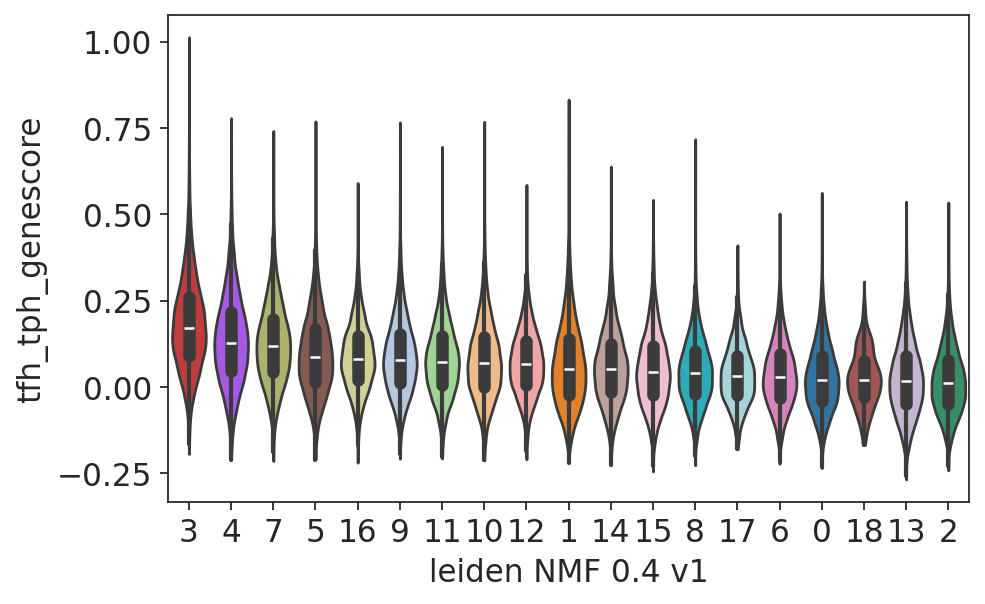

In [19]:
sns.set_style("ticks")
with plt.rc_context({"figure.figsize": (6, 4)}):
    sc.pl.violin(
        cd4mem_adata_sub,
        ["tfh_tph_genescore"],
        groupby="leiden_NMF_0.4_v1",
        order=median_by_cluster.index.values,
        stripplot=False,  # remove the internal dots
        inner="box",  # adds a boxplot inside violins
        save=proj_name + "_tfh_tph_score.pdf",
    )
# sc.pl.violin(pair_mono_adata, 'c8_score', stripplot=False, groupby='AIFI_L3_new')

In [46]:
import scikit_posthocs as sp
import statsmodels.api as sm
from scipy import stats
from scipy.stats import kruskal
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

df = (
    cd4mem_adata_sub.obs[["tfh_tph_genescore", "leiden_NMF_0.4_v1"]]
    .dropna()
    .copy()
    .rename(columns={"leiden_NMF_0.4_v1": "leiden"})
)


# Group the scores by cluster
groups = [group["tfh_tph_genescore"].values for _, group in df.groupby("leiden")]

# Run Kruskal-Wallis test
stat, p_value = kruskal(*groups)
print(f"Kruskal-Wallis H-test statistic = {stat}, p = {p_value}")

# If significant, run pairwise Dunn's test
if p_value < 0.05:
    dunn_result = sp.posthoc_dunn(
        df, val_col="tfh_tph_genescore", group_col="leiden", p_adjust="bonferroni"
    )
    print("\nPairwise Dunn's Test (Bonferroni-corrected p-values):")
    print(dunn_result.round(4))

Kruskal-Wallis H-test statistic = 62895.50662366675, p = 0.0

Pairwise Dunn's Test (Bonferroni-corrected p-values):
         0       1    2    3    4    5    6    7       8    9     10     11  \
0   1.0000  0.0000  0.0  0.0  0.0  0.0  0.0  0.0  0.0000  0.0  0.000  0.000   
1   0.0000  1.0000  0.0  0.0  0.0  0.0  0.0  0.0  0.0000  0.0  0.000  0.000   
2   0.0000  0.0000  1.0  0.0  0.0  0.0  0.0  0.0  0.0000  0.0  0.000  0.000   
3   0.0000  0.0000  0.0  1.0  0.0  0.0  0.0  0.0  0.0000  0.0  0.000  0.000   
4   0.0000  0.0000  0.0  0.0  1.0  0.0  0.0  0.0  0.0000  0.0  0.000  0.000   
5   0.0000  0.0000  0.0  0.0  0.0  1.0  0.0  0.0  0.0000  0.0  0.000  0.000   
6   0.0000  0.0000  0.0  0.0  0.0  0.0  1.0  0.0  0.0000  0.0  0.000  0.000   
7   0.0000  0.0000  0.0  0.0  0.0  0.0  0.0  1.0  0.0000  0.0  0.000  0.000   
8   0.0000  0.0000  0.0  0.0  0.0  0.0  0.0  0.0  1.0000  0.0  0.000  0.000   
9   0.0000  0.0000  0.0  0.0  0.0  0.0  0.0  0.0  0.0000  1.0  0.000  0.000   
10  0.0000  0.0

In [44]:
from scipy.stats import mannwhitneyu

# Choose your target cluster
target_cluster = "3"  # example: cluster '3'

# Split data
target = df[df["leiden"] == target_cluster]["tfh_tph_genescore"]
others = df[df["leiden"] == "7"]["tfh_tph_genescore"]

# Run Mann-Whitney U Test
stat, p_value = mannwhitneyu(target, others, alternative="two-sided")
print(f"Mann-Whitney U statistic = {stat}, p = {p_value:.4f}")

Mann-Whitney U statistic = 603953609.5, p = 0.0000


In [39]:
p_value

np.float64(0.0)